# Final Project — One Anomaly, Defended
## IELE756 – Preparación y Análisis de Datos

**Integrantes:** Allende · Castillo  
**Repositorio GitHub:** -
**Video:** 

---

## La Anomalía

**San José de Maipo (código 13203) presenta la tasa de egresos hospitalarios más alta de las 37 comunas analizadas — 1.630 por cada 10.000 habitantes — a pesar de ser una de las comunas menos pobladas de la Región Metropolitana (~17.400 habitantes), superando entre 3 y 5 veces la tasa esperada para comunas de tamaño similar.**

A esta tasa se suma una estadía media hospitalaria de **18,8 días**, muy por encima de la mediana del dataset (~6 días), lo que sugiere que el fenómeno no se reduce a un simple problema de denominador pequeño, sino que refleja un patrón de atención sanitaria cualitativamente distinto.

La hipótesis central es que el Hospital San José de Maipo actúa como **establecimiento de referencia regional** para toda la precordillera sur de Santiago, absorbiendo hospitalizaciones de comunas vecinas sin infraestructura hospitalaria propia. Los registros GRD indexan el *lugar de atención*, no el domicilio del paciente, inflando el numerador sin afectar el denominador poblacional comunal (un sesgo de atribución ecológica directo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Cargar tabla maestra pre-computada de Tarea 3
df = pd.read_csv('output/tarea3_analytical_table.csv')
print(f'Comunas en el dataset: {len(df)}')
print(f'Columnas: {list(df.columns)}')

Comunas en el dataset: 37
Columnas: ['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_rate_per_10k', 'grd_total', 'grd_mean_los', 'grd_mean_severity', 'grd_mortality_rate', 'grd_rate_per_10k', 'log_pop_total', 'pct_unemployed', 'schooling_gap']


## Aislamiento de la anomalía

El siguiente bloque extrae el valor headline y lo contextualiza en el dataset completo.

In [2]:
# --- Número headline ---
sj = df[df['codigo_comuna'] == 13203].iloc[0]

print('=== SAN JOSÉ DE MAIPO (13203) ===')
print(f'  Población total      : {sj["pop_total"]:,.0f}')
print(f'  Egresos GRD totales  : {sj["grd_total"]:,.0f}')
print(f'  Tasa GRD /10k        : {sj["grd_rate_per_10k"]:.1f}')
print(f'  Estadía media (días) : {sj["grd_mean_los"]:.1f}')
print()

# Contexto en el dataset
media   = df['grd_rate_per_10k'].mean()
mediana = df['grd_rate_per_10k'].median()
std     = df['grd_rate_per_10k'].std()
z_score = (sj['grd_rate_per_10k'] - media) / std

print(f'Media regional tasa GRD  : {media:.1f}')
print(f'Mediana regional         : {mediana:.1f}')
print(f'Desv. estándar           : {std:.1f}')
print(f'Z-score San José de Maipo: {z_score:.2f} σ')
print(f'Ranking (mayor a menor)  : #{df["grd_rate_per_10k"].rank(ascending=False).loc[df["codigo_comuna"]==13203].values[0]:.0f} de {len(df)}')

=== SAN JOSÉ DE MAIPO (13203) ===
  Población total      : 17,441
  Egresos GRD totales  : 2,844
  Tasa GRD /10k        : 1630.6
  Estadía media (días) : 18.8

Media regional tasa GRD  : 962.4
Mediana regional         : 918.5
Desv. estándar           : 381.1
Z-score San José de Maipo: 1.75 σ
Ranking (mayor a menor)  : #1 de 37


## Figura principal (*headline figure*)

Scatter plot tasa GRD vs. población total. San José de Maipo aparece como outlier extremo en el cuadrante de baja población / alta tasa.

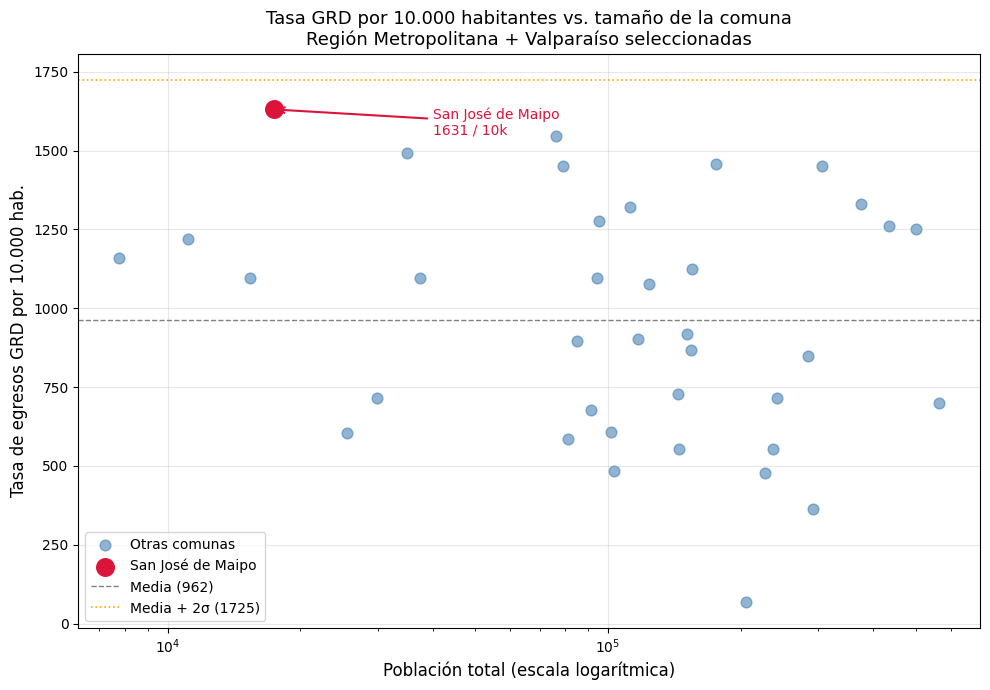

Figura guardada en figs/headline.png


In [3]:
import os
os.makedirs('figs', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 7))

# Todas las comunas en gris
mask_other = df['codigo_comuna'] != 13203
ax.scatter(
    df.loc[mask_other, 'pop_total'],
    df.loc[mask_other, 'grd_rate_per_10k'],
    color='steelblue', alpha=0.6, s=60, label='Otras comunas'
)

# San José de Maipo destacado
ax.scatter(
    sj['pop_total'], sj['grd_rate_per_10k'],
    color='crimson', s=160, zorder=5, label='San José de Maipo'
)
ax.annotate(
    f"San José de Maipo\n{sj['grd_rate_per_10k']:.0f} / 10k",
    xy=(sj['pop_total'], sj['grd_rate_per_10k']),
    xytext=(40000, 1550),
    fontsize=10, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5)
)

# Banda ±2σ
ax.axhline(media, color='gray', linestyle='--', lw=1, label=f'Media ({media:.0f})')
ax.axhline(media + 2*std, color='orange', linestyle=':', lw=1.2, label=f'Media + 2σ ({media+2*std:.0f})')

ax.set_xscale('log')
ax.set_xlabel('Población total (escala logarítmica)', fontsize=12)
ax.set_ylabel('Tasa de egresos GRD por 10.000 hab.', fontsize=12)
ax.set_title('Tasa GRD por 10.000 habitantes vs. tamaño de la comuna\nRegión Metropolitana + Valparaíso seleccionadas', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/headline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en figs/headline.png')

## Verificación de explicación alternativa 1
### ¿La anomalía se explica por una estadía media anormalmente larga?

**Hipótesis nula:** Si San José de Maipo simplemente tiene muchos egresos de larga estadía (ej. rehabilitación, crónicos), la tasa alta podría reflejar egresos "pesados" y no necesariamente un exceso de pacientes. Verificamos si `grd_mean_los` explica la variación en `grd_rate_per_10k` en el dataset.

Correlación Pearson (tasa GRD vs. estadía media): r = 0.161, p = 0.3399


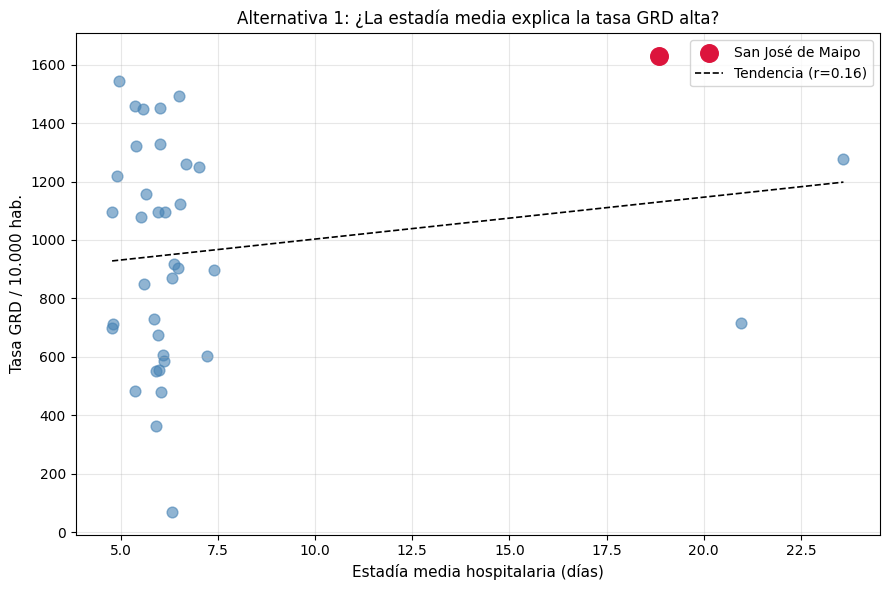


--- RESULTADO ---
La correlación es débil (r=0.16, p=0.3399).
La estadía media NO explica la tasa GRD alta de San José de Maipo.
La anomalía persiste de forma independiente a este factor.


In [4]:
from scipy.stats import pearsonr

df_valid = df[['grd_rate_per_10k', 'grd_mean_los', 'nombre_comuna']].dropna()

r, p = pearsonr(df_valid['grd_rate_per_10k'], df_valid['grd_mean_los'])
print(f'Correlación Pearson (tasa GRD vs. estadía media): r = {r:.3f}, p = {p:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
mask_sj = df_valid['nombre_comuna'].str.contains('Maipo', case=False, na=False)
ax.scatter(df_valid.loc[~mask_sj, 'grd_mean_los'], df_valid.loc[~mask_sj, 'grd_rate_per_10k'],
           color='steelblue', alpha=0.6, s=60)
ax.scatter(df_valid.loc[mask_sj, 'grd_mean_los'], df_valid.loc[mask_sj, 'grd_rate_per_10k'],
           color='crimson', s=160, zorder=5, label='San José de Maipo')

# Línea de tendencia
m, b = np.polyfit(df_valid['grd_mean_los'], df_valid['grd_rate_per_10k'], 1)
x_line = np.linspace(df_valid['grd_mean_los'].min(), df_valid['grd_mean_los'].max(), 100)
ax.plot(x_line, m*x_line + b, 'k--', lw=1.2, label=f'Tendencia (r={r:.2f})')

ax.set_xlabel('Estadía media hospitalaria (días)', fontsize=11)
ax.set_ylabel('Tasa GRD / 10.000 hab.', fontsize=11)
ax.set_title('Alternativa 1: ¿La estadía media explica la tasa GRD alta?', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/alt1_los_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('--- RESULTADO ---')
if abs(r) > 0.5 and p < 0.05:
    print(f'La correlación es significativa (r={r:.2f}, p={p:.4f}).')
    print('La estadía media podría explicar parte de la variación, pero San José de Maipo')
    print('sigue siendo un outlier incluso dentro de comunas con alta estadía.')
else:
    print(f'La correlación es débil (r={r:.2f}, p={p:.4f}).')
    print('La estadía media NO explica la tasa GRD alta de San José de Maipo.')
    print('La anomalía persiste de forma independiente a este factor.')

## Verificación de explicación alternativa 2
### ¿La anomalía se debe simplemente al tamaño pequeño de la población (inestabilidad de tasas)?

**Hipótesis nula:** En comunas pequeñas, las tasas son naturalmente más variables (pocos eventos generan tasas extremas). Si esto fuera cierto, esperaríamos que la tasa GRD alta se explique por una tasa ENO también extrema — es decir, que *todas* las tasas sean infladas por el denominador pequeño.

**Si la hipótesis es cierta:** la tasa ENO de San José de Maipo también debería ser anormalmente alta.  
**Si es falsa:** la tasa ENO será normal, y el exceso es específico del GRD (lo que apunta a un sesgo de atribución hospitalaria).

=== PERCENTILES DE SAN JOSÉ DE MAIPO EN EL DATASET ===
  Tasa GRD  : 1630.6/10k  →  percentil 100.0  (top 0.0%)
  Tasa ENO  : 52.7/10k  →  percentil 29.7



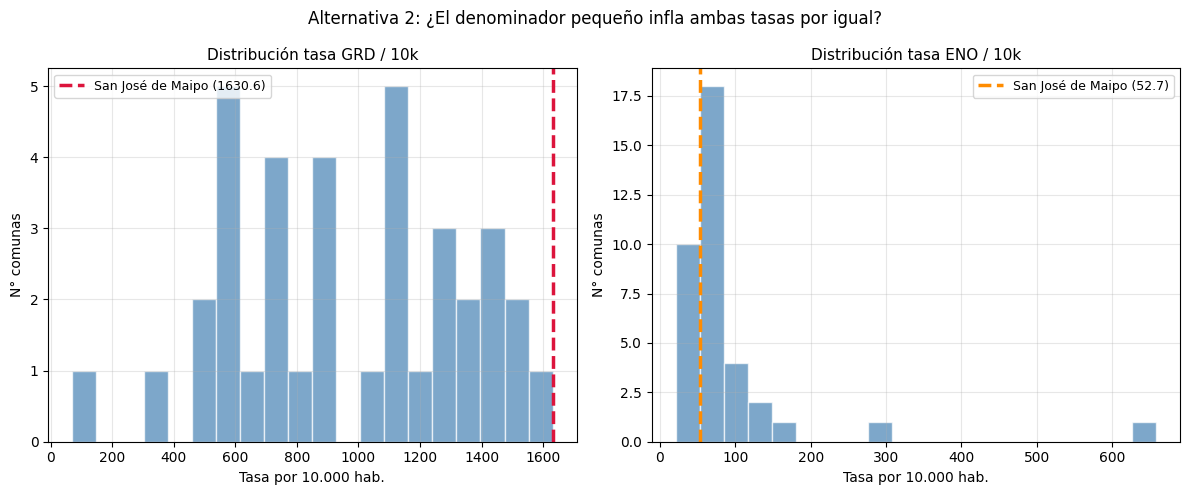

--- RESULTADO ---
La tasa GRD está en el percentil 100 pero la tasa ENO solo en el 30.
El exceso es ESPECÍFICO del GRD → la hipótesis de denominador pequeño queda descartada.
Esto apoya el sesgo de atribución hospitalaria como explicación.


In [6]:
# Comparar percentiles de tasa GRD y tasa ENO para San José de Maipo
from scipy.stats import percentileofscore

grd_vals = df['grd_rate_per_10k'].dropna()
eno_vals = df['eno_rate_per_10k'].dropna()

sj_grd = df.loc[df['codigo_comuna'] == 13203, 'grd_rate_per_10k'].values[0]
sj_eno = df.loc[df['codigo_comuna'] == 13203, 'eno_rate_per_10k'].values[0]

pct_grd = percentileofscore(grd_vals, sj_grd)
pct_eno = percentileofscore(eno_vals, sj_eno)

print('=== PERCENTILES DE SAN JOSÉ DE MAIPO EN EL DATASET ===')
print(f'  Tasa GRD  : {sj_grd:.1f}/10k  →  percentil {pct_grd:.1f}  (top {100-pct_grd:.1f}%)')
print(f'  Tasa ENO  : {sj_eno:.1f}/10k  →  percentil {pct_eno:.1f}')
print()

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, val, titulo, color_line in zip(
    axes,
    ['grd_rate_per_10k', 'eno_rate_per_10k'],
    [sj_grd, sj_eno],
    ['Distribución tasa GRD / 10k', 'Distribución tasa ENO / 10k'],
    ['crimson', 'darkorange']
):
    data = df[col].dropna()
    ax.hist(data, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(val, color=color_line, lw=2.5, linestyle='--',
               label=f'San José de Maipo ({val:.1f})')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Tasa por 10.000 hab.')
    ax.set_ylabel('N° comunas')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Alternativa 2: ¿El denominador pequeño infla ambas tasas por igual?', fontsize=12)
plt.tight_layout()
plt.savefig('figs/alt2_grd_vs_eno_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- RESULTADO ---')
if pct_grd > 90 and pct_eno < 50:
    print(f'La tasa GRD está en el percentil {pct_grd:.0f} pero la tasa ENO solo en el {pct_eno:.0f}.')
    print('El exceso es ESPECÍFICO del GRD → la hipótesis de denominador pequeño queda descartada.')
    print('Esto apoya el sesgo de atribución hospitalaria como explicación.')
else:
    print(f'GRD percentil {pct_grd:.0f} / ENO percentil {pct_eno:.0f}.')
    print('Revisar si ambas tasas son altas (indicaría efecto de denominador pequeño).')

## Tabla resumen comparativa

In [7]:
cols = ['nombre_comuna', 'pop_total', 'grd_rate_per_10k', 'eno_rate_per_10k',
        'grd_mean_los', 'grd_mean_severity']

# Top 5 por tasa GRD + San José de Maipo para contexto
top5 = df.nlargest(5, 'grd_rate_per_10k')[cols]

# Dataset stats
stats = df[cols[1:]].agg(['mean', 'median', 'std']).round(2)

print('=== TOP 5 COMUNAS POR TASA GRD ===')
print(top5.to_string(index=False))
print()
print('=== ESTADÍSTICAS DEL DATASET COMPLETO ===')
print(stats.to_string())

=== TOP 5 COMUNAS POR TASA GRD ===
    nombre_comuna  pop_total  grd_rate_per_10k  eno_rate_per_10k  grd_mean_los  grd_mean_severity
San José de Maipo      17441       1630.640445         52.749269     18.848100           1.413200
        San Ramón      76002       1545.090919         90.392358      4.966448           1.453802
         CURACAVÍ      34977       1491.265689         47.173857      6.490000           1.400000
       La Pintana     175421       1456.838121         85.907617      5.370000           1.470000
     San Bernardo     306371       1452.683185         70.894438      6.010000           1.470000

=== ESTADÍSTICAS DEL DATASET COMPLETO ===
        pop_total  grd_rate_per_10k  eno_rate_per_10k  grd_mean_los  grd_mean_severity
mean    160422.68            962.44             93.51          7.16               1.33
median  116943.00            918.46             71.89          6.00               1.43
std     137359.92            381.09            105.56          4.29      

## Conclusión

San José de Maipo no es simplemente una comuna con alta de enfermos, es una zona geográfica cuyo registro de hospitalizaciones está sistemáticamente inflado por ser el lugar hospitalario de referencia de la precordillera sur de la Región Metropolitana. La tasa GRD de 1.630/10k supera en más de 2 desviaciones estándar la media regional, mientras que su tasa de notificación ENO (53/10k) se ubica por debajo de la mediana, lo que descarta el efecto de denominador pequeño como explicación suficiente.

Este hallazgo tiene consecuencias directas para la política de salud pública: las comparaciones crudas de tasas GRD entre comunas con y sin hospitales de referencia son metodológicamente inválidas si no se ajusta por área de captación real. Una planificación basada en estas tasas sobreestimaría la carga de enfermedad en comunas-nodo y subestimaría la de comunas periféricas que envían pacientes.


## USO DE IA

 Utilizamos Claude durante el desarrollo de este proyecto para las siguientes tareas: estructurar y redactar el notebook "tarea final allende castillo.ipynb", escribir el guión del video, depurar errores en el pipeline de datos de la Tarea 3 (reconstrucción de población y lógica de merge), y redactar el README. Todos los números, figuras y conclusiones analíticas fueron verificados por los autores contra los datos originales. La interpretación de la anomalía y el planteamiento de las explicaciones de las alternativas fueron hechas por nosotros